In [1]:
import os, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from itertools import combinations
import seaborn as sns
from statsmodels.stats.multitest import multipletests



plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica"]


dates={"CW1A": "2024-07-25", "CW2A": "2024-08-01", "CW3A": "2024-08-07", "EXPUPS1A": "2024-07-25", "EXPUPS2A": "2024-08-01", "EXPUPS3A": "2024-08-07", "EXPMDS1B": "2024-07-25", "EXPMDS2B": "2024-08-01", 
 "EXPDWS1C": "2024-07-25", "EXPDWS2C": "2024-08-01", "EXPDWS3C": "2024-08-07",
 "PETUPS1A": "2024-07-25", "PETUPS2A": "2024-08-01", "PETUPS3A": "2024-08-07",  "PETDWS2B": "2024-08-01",   "PETDWS2C": "2024-08-01",  "MBUPS1A": "2024-07-25", "MBUPS2A": "2024-08-01", "MBUPS3A": "2024-08-07",
 "MBMDS1B": "2024-07-25", "MBMDS2B": "2024-08-01", "MBMDS3B": "2024-08-07","MBDWS1C": "2024-07-25", "MBDDWS2C": "2024-08-01", "MBDWS3C": "2024-08-07","AJBUPS1A": "2024-07-25", "AJBUPS2A": "2024-08-01", "AJBUPS3A": "2024-08-07", "AJBMDS2B": "2024-08-01", "AJBMDS3B": "2024-08-07",
 "AJBDWS1C": "2024-07-25", "AJBDWS2C": "2024-08-01", "AJBDWS3C": "2024-08-07", "AJA1A": "2024-07-25", "AJA2A": "2024-08-01", "AJA3A": "2024-08-07"}

MT=[]
for f in glob.glob("*EsViritu.detected_virus.info.tsv"):
    df=pd.read_csv(f, sep="\t")
    MT.append(df)

MT=pd.concat(MT)
MT["Cov_perc"] = MT["covered_bases"] / MT["Asm_length"] * 100
MT = MT.drop(columns=['kingdom', 'phylum', 'tclass', 'order','Segment', 'Assembly'], errors='ignore')
MT=MT[MT["covered_bases"]>=1000]
MT["canal"]=[re.sub("MBD", "MB", x.split("_")[0]) for x in MT["sample_ID"]]
MT["dates"]=MT["sample_ID"].str.replace("_", "").map(dates)

26
62
136


In [4]:
MT["family"]=MT["family"].str.replace("f__", "")

In [5]:
tdf=pd.read_csv("read_counts_seqkit.csv")
tdf["sample"]=tdf["file"].str.replace(".AACMFLCHV.1.cleaned_bbdukclean_R1.fastq.gz", "")
rr=dict(zip(tdf["sample"], tdf["num_seqs"]))
MT["total_reads"]=MT["sample_ID"].map(rr)
# pp["RPM"]=(pp["taxReads"]/pp["total_reads"])*1000000

In [41]:
rpm_df = MT.dropna(subset=["canal", "family"]).groupby(["canal", "family"], as_index=False).agg(read_count=("read_count", "sum"),total_reads=("total_reads", "sum"))
rpm_df["RPM"] = rpm_df["read_count"] / rpm_df["total_reads"] * 1000000

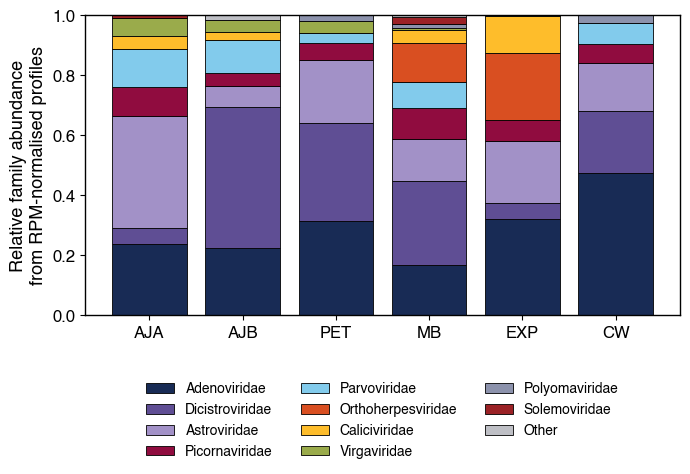

In [7]:
cols = ['#182b55', '#5f4e94', '#a291c7', '#900c3f', '#82cbec', '#d94f21','#febd2b', '#9aab4b', "#8C92AC", "#9b2226", "#6a4c93", "#1982c4","#8ac926", "#ff595e", "#FFFDD0", "#ffca3a", "#8338ec", "#3a86ff"]


plot_df = rpm_df.copy()
plot_df["RPM"] = pd.to_numeric(plot_df["RPM"], errors="coerce").fillna(0)
plot_df["family"] = plot_df["family"].astype(str).str.replace("f__", "", regex=False)
cf = plot_df.groupby(["canal", "family"], as_index=False)["RPM"].sum()

top_f = cf.groupby("family")["RPM"].sum().sort_values(ascending=False).head(10).index.tolist()

cf["family_collapsed"] = np.where(cf["family"].isin(top_f),cf["family"],"Other")
cfc = cf.groupby(["canal", "family_collapsed"], as_index=False)["RPM"].sum().rename(columns={"family_collapsed": "family"})

crpm = cfc.pivot(index="canal", columns="family", values="RPM").fillna(0)
c_rel = crpm.div(crpm.sum(axis=1), axis=0).fillna(0)

co = ["AJA", "AJB", "PET", "MB", "EXP", "CW"]
co = [c for c in co if c in c_rel.index]
c_rel = c_rel.loc[co]
f_o = c_rel.drop(columns=["Other"], errors="ignore").sum(axis=0).sort_values(ascending=False).index.tolist()


if "Other" in c_rel.columns:
    f_o = f_o + ["Other"]

c_rel = c_rel[f_o]

c_m = {fam: cols[i % len(cols)]  for i, fam in enumerate([f for f in f_o if f != "Other"])}
c_m["Other"] = "#BEBFC5"

fig, ax = plt.subplots(figsize=(7, 5))
bottom = np.zeros(len(c_rel))

for fam in f_o:
    vals = c_rel[fam].values
    ax.bar(c_rel.index, vals, bottom=bottom, label=fam, color=c_m[fam], edgecolor="black", linewidth=0.6)
    bottom += vals

ax.set_xlabel("")
ax.set_ylabel("Relative family abundance\nfrom RPM-normalised profiles", fontsize=13)
ax.set_ylim(0, 1)

ax.tick_params(axis="x", labelsize=12, colors="black")
ax.tick_params(axis="y", labelsize=12, colors="black")

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1)

ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False, fontsize=10)

ax.grid(False)

plt.tight_layout()
plt.show()

In [8]:
plot_df = rpm_df.copy()
plot_df["RPM"] = pd.to_numeric(plot_df["RPM"], errors="coerce").fillna(0)

plot_df["family"] = plot_df["family"].astype(str).str.replace("f__", "", regex=False)


cf_rpm_sum = plot_df.groupby(["canal", "family"], as_index=False)["RPM"].sum()
c_rpm = cf_rpm_sum.pivot(index="canal", columns="family", values="RPM").fillna(0)

c_rel = c_rpm.div(c_rpm.sum(axis=1),axis=0).fillna(0)
c_rel = c_rel.loc[co]
families = c_rel.sum(axis=0).sort_values(ascending=False).index.tolist()
c_rel = c_rel[families]


bc_m = pd.DataFrame(squareform(pdist(c_rel.values, metric="braycurtis")), index=c_rel.index, columns=c_rel.index)

bc_m

family,Adenoviridae,Dicistroviridae,Astroviridae,Picornaviridae,Parvoviridae,Orthoherpesviridae,Caliciviridae,Virgaviridae,Polyomaviridae,Solemoviridae,Tombusviridae
canal,,,,,,,,,,,
AJA,0.236496,0.053859,0.372323,0.098213,0.127144,0.000000,0.041612,0.060341,0.000000,0.010012,0.000000
AJB,0.225430,0.467946,0.069392,0.044834,0.110041,0.000000,0.025305,0.042747,0.000000,0.000000,0.014306
PET,0.312488,0.328451,0.209492,0.058612,0.032181,0.000000,0.000000,0.039168,0.019609,0.000000,0.000000
MB,0.167427,0.281589,0.139592,0.103029,0.085002,0.129882,0.043286,0.008890,0.012278,0.024861,0.004165
EXP,0.322235,0.052004,0.205714,0.070073,0.000000,0.224317,0.123326,0.002331,0.000000,0.000000,0.000000
CW,0.475723,0.203662,0.161142,0.062897,0.072431,0.000000,0.000000,0.000000,0.024144,0.000000,0.000000


canals: right arm: AJB>PET>MB>EXP>CW
left arm: AJA>MB>EXP>CW


canal,AJA,AJB,PET,MB,EXP,CW
canal,,,,,,
AJA,0.000000,0.428393,0.370194,0.395393,0.391771,0.413175
AJB,0.428393,0.000000,0.260544,0.313397,0.580704,0.384251
PET,0.370194,0.260544,0.000000,0.299431,0.368851,0.212306
MB,0.395393,0.313397,0.299431,0.000000,0.395405,0.341713
EXP,0.391771,0.580704,0.368851,0.395405,0.000000,0.401721
CW,0.413175,0.384251,0.212306,0.341713,0.401721,0.000000


In [12]:
distances = { ("AJB", "PET"): 0.44, ("AJB", "MB"): 1.65, ("AJB", "EXP"): 1.75,("AJB", "CW"): 2.70,("AJB", "AJA"): 1, ("PET", "MB"): 1.25, ("PET", "EXP"): 1.30, 
              ("PET", "CW"): 2.27, ("PET", "AJA"): 0.6,("AJA", "MB"): 1.20, ("AJA", "EXP"): 1.30,("AJA", "CW"): 2.25, ("MB", "EXP"): 0.10,("MB", "CW"): 1.10,("EXP", "CW"): 1.00,}

In [44]:
bcm = pd.DataFrame(squareform(pdist(c_rel.values, metric="braycurtis")), index=c_rel.index, columns=c_rel.index)

decay_r = []
for (c1, c2), dist in distances.items():
    if c1 in bcm.index and c2 in bc_matrix.columns:
        bc = bcm.loc[c1, c2]
        decay_r.append({"canal_1": c1, "canal_2": c2, "pair": f"{c1}-{c2}", "distance_km": dist, "bray_curtis": bc, "similarity": 1 - bc})

decay_df = pd.DataFrame(decadecay_ry_rows)
decay_df = decay_df.sort_values("distance_km")
decay_df

,canal_1,canal_2,pair,distance_km,bray_curtis,similarity
12,MB,EXP,MB-EXP,0.10,0.395405,0.604595
0,AJB,PET,AJB-PET,0.44,0.260544,0.739456
8,PET,AJA,PET-AJA,0.60,0.370194,0.629806
4,AJB,AJA,AJB-AJA,1.00,0.428393,0.571607
14,EXP,CW,EXP-CW,1.00,0.401721,0.598279
13,MB,CW,MB-CW,1.10,0.341713,0.658287
9,AJA,MB,AJA-MB,1.20,0.395393,0.604607
5,PET,MB,PET-MB,1.25,0.299431,0.700569
6,PET,EXP,PET-EXP,1.30,0.368851,0.631149
10,AJA,EXP,AJA-EXP,1.30,0.391771,0.608229


In [ ]:
rho, pval = spearmanr(decay_df["distance_km"],decay_df["bray_curtis"])

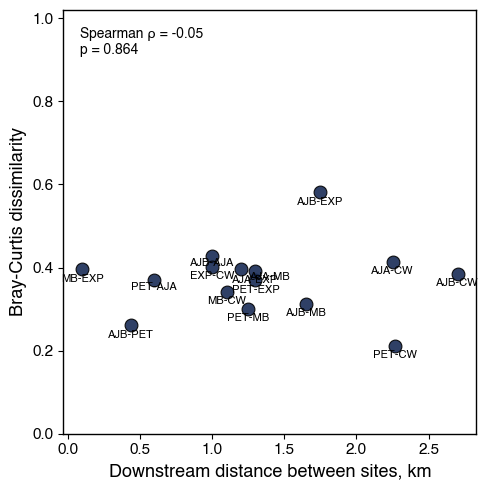

In [46]:
loffs = {"AJB-PET": (0.00, -0.01), "AJB-MB":  (0.00, -0.01), "AJB-EXP": (0.00, -0.01), "AJB-CW":  (0.00, -0.01), "PET-MB":  (0.00, -0.01), "PET-EXP": (0.00, -0.01), "PET-CW":  (0.00, -0.01), "AJA-MB":  (0.2, -0.005), "AJA-EXP": (0.00, -0.01), "AJA-CW":  (0.00, -0.01), "MB-EXP":  (0.00, -0.01), "MB-CW":   (0.00, -0.01),  "EXP-CW":  (0.00, -0.01),}

fig, ax = plt.subplots(figsize=(5, 5))

sns.scatterplot(data=decay_df, x="distance_km", y="bray_curtis", s=85, edgecolor="black", linewidth=0.8, alpha=0.9, color="#182b55", ax=ax)

for _, row in decay_df.iterrows():
    dx, dy = loffs.get(row["pair"], (0.00, -0.005))
    ax.text(row["distance_km"] + dx, row["bray_curtis"] + dy, row["pair"], fontsize=8, ha="center", va="top", color="black")

ax.text(0.04, 0.96, f"Spearman ρ = {rho:.2f}\np = {pval:.3g}", transform=ax.transAxes, ha="left", va="top",fontsize=10)

ax.set_xlabel("Downstream distance between sites, km", fontsize=13)
ax.set_ylabel("Bray-Curtis dissimilarity", fontsize=13)

ax.tick_params(axis="x", labelsize=11, colors="black")
ax.tick_params(axis="y", labelsize=11, colors="black")
ax.set_ylim(0,1)

ymin, ymax = ax.get_ylim()
ax.set_ylim(max(0, ymin - 0.05), ymax + 0.02)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1)

ax.grid(False)
plt.tight_layout()

plt.show()

In [47]:
rpm_df = MT.dropna(subset=["canal", "dates", "family"]).groupby(["canal","dates", "family"], as_index=False).agg(read_count=("read_count", "sum"),total_reads=("total_reads", "sum"))
rpm_df["RPM"] = rpm_df["read_count"] / rpm_df["total_reads"] * 1000000
rpm_df

,canal,dates,family,read_count,total_reads,RPM
0,AJA,2024-07-25,Adenoviridae,112,80692114,1.387992
1,AJA,2024-07-25,Astroviridae,521,121038171,4.304427
2,AJA,2024-07-25,Dicistroviridae,771,121038171,6.369891
3,AJA,2024-07-25,Picornaviridae,280,80692114,3.469980
4,AJA,2024-07-25,Solemoviridae,80,40346057,1.982846
...,...,...,...,...,...,...
102,PET,2024-08-07,Adenoviridae,5677,27691564,205.008283
103,PET,2024-08-07,Astroviridae,542,13845782,39.145496
104,PET,2024-08-07,Dicistroviridae,1427,6922891,206.127758
105,PET,2024-08-07,Picornaviridae,672,20768673,32.356425


In [ ]:
df = rpm_df.copy()
df["dates"] = pd.to_datetime(df["dates"])
df["RPM"] = pd.to_numeric(df["RPM"], errors="coerce").fillna(0)

df = df.groupby(["canal", "dates", "family"], as_index=False)["RPM"].sum()


def bray_curtis_family_contributions(group, date_value):
    wide = group.pivot_table(index="canal", columns="family", values="RPM", fill_value=0, aggfunc="sum")
    rr = []
    for c1, c2 in combinations(wide.index, 2):
        x = wide.loc[c1]
        y = wide.loc[c2]
        
        abs_diff = (x - y).abs()
        abundance_sum = x + y
        numerator = abs_diff.sum()
        denominator = abundance_sum.sum()
        bray_curtis = numerator / denominator if denominator > 0 else np.nan
        for family in wide.columns:
            family_abs_diff = abs_diff[family]
            c_to_diff = (family_abs_diff / numerator * 100 if numerator > 0 else np.nan)
            c_bc = (family_abs_diff / denominator * 100  if denominator > 0 else np.nan )
            rr.append({ "dates": date_value, "canal_1": c1, "canal_2": c2, "family": family, "RPM_1": x[family],"RPM_2": y[family], "abs_difference": family_abs_diff, "bray_curtis": bray_curtis, "percent_contribution_to_difference": c_to_diff, "percent_contribution_to_bray_curtis": c_bc })
    
    return pd.DataFrame(rr)



out = []
for date_value, group in df.groupby("dates"):
    tmp = bray_curtis_family_contributions(group, date_value)
    out.append(tmp)
family_contrib = pd.concat(out, ignore_index=True)


In [ ]:
high_bc = family_contrib[family_contrib["bray_curtis"] >= 0.5].copy()
# high_bc["dates"] = pd.to_datetime(high_bc["dates"]).dt.strftime("%Y-%m-%d")
high_bc_pair= high_bc[["dates", "canal_1", "canal_2", "bray_curtis"]].drop_duplicates().sort_values(["dates", "bray_curtis"], ascending=[True, False])

In [49]:
high_bc_family_summary = high_bc.groupby("family", as_index=False).agg(n_high_bc_pairs=("percent_contribution_to_difference", "count"), mean_percent_contribution=("percent_contribution_to_difference", "mean"), median_percent_contribution=("percent_contribution_to_difference", "median"), max_percent_contribution=("percent_contribution_to_difference", "max"), mean_abs_difference=("abs_difference", "mean"), median_abs_difference=("abs_difference", "median")).sort_values("mean_percent_contribution", ascending=False)
high_bc_family_summary.head(15)

,family,n_high_bc_pairs,mean_percent_contribution,median_percent_contribution,max_percent_contribution,mean_abs_difference,median_abs_difference
0,Adenoviridae,30,29.326954,18.937113,75.837817,512.158483,108.983605
3,Dicistroviridae,30,26.190135,12.863660,76.375391,162.760815,71.243383
1,Astroviridae,30,18.908242,8.585164,62.275395,140.588114,80.681229
6,Picornaviridae,30,7.054255,5.625718,23.445490,74.003276,33.624435
5,Parvoviridae,16,6.699512,4.970838,16.390056,50.571643,30.606666
2,Caliciviridae,30,5.104621,2.185571,32.200657,43.352029,20.604488
4,Orthoherpesviridae,21,4.177556,0.000000,15.604534,70.697792,0.000000
8,Solemoviridae,30,4.141826,0.418568,35.483790,26.241831,1.982846
10,Virgaviridae,30,1.774459,0.953588,7.820127,9.252852,7.123259
7,Polyomaviridae,30,0.806251,0.054061,3.769068,5.129220,0.449781


In [50]:
top3_high_bc = high_bc.sort_values(["dates", "canal_1", "canal_2", "percent_contribution_to_difference"],ascending=[True, True, True, False]).groupby(["dates", "canal_1", "canal_2"]).head(3)
top_d = top3_high_bc.groupby("family", as_index=False).agg(times_in_top3=("family", "count"), mean_top3_contribution=("percent_contribution_to_difference", "mean"), median_top3_contribution=("percent_contribution_to_difference", "median"), max_top3_contribution=("percent_contribution_to_difference", "max")).sort_values(["times_in_top3", "mean_top3_contribution"], ascending=[False, False])

top_d

,family,times_in_top3,mean_top3_contribution,median_top3_contribution,max_top3_contribution
0,Adenoviridae,26,32.966854,20.555747,75.837817
1,Astroviridae,20,25.818985,19.847213,62.275395
3,Dicistroviridae,16,44.846989,45.893183,76.375391
6,Picornaviridae,12,11.325052,9.597077,23.445490
4,Orthoherpesviridae,5,13.087354,14.436797,15.604534
7,Solemoviridae,4,27.587491,26.787277,35.483790
2,Caliciviridae,3,27.048113,24.963721,32.200657
5,Parvoviridae,3,9.588095,7.808091,14.579041
8,Virgaviridae,1,7.210692,7.210692,7.210692


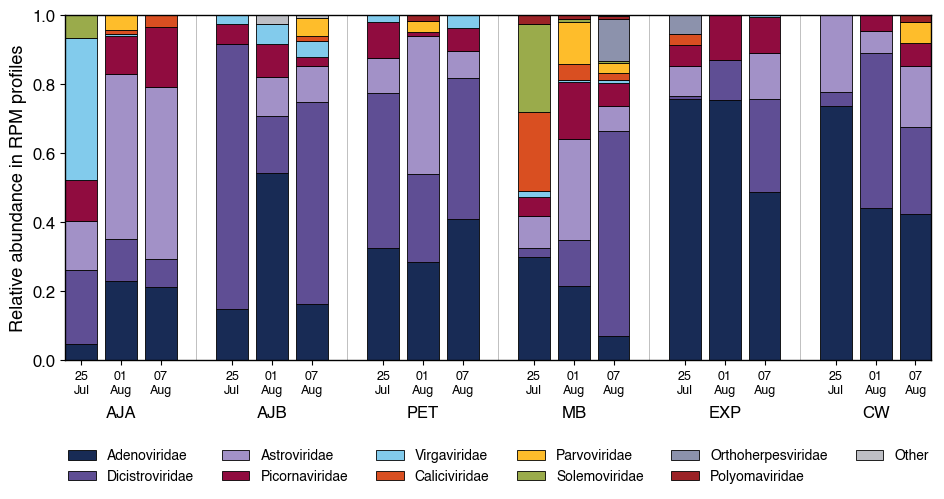

In [53]:
plot_df = rpm_df.copy()
plot_df["RPM"] = pd.to_numeric(plot_df["RPM"], errors="coerce").fillna(0)
plot_df["family"] = plot_df["family"].astype(str).str.replace("f__", "", regex=False)
plot_df["dates"] = pd.to_datetime(plot_df["dates"])
plot_df["date_label"] = plot_df["dates"].dt.strftime("%Y-%m-%d")
cdf = plot_df.groupby(["canal", "date_label", "family"], as_index=False)["RPM"].sum()


top_f = cdf.groupby("family")["RPM"].sum().sort_values(ascending=False).head(10).index.tolist()
cdf["family_collapsed"] = np.where(cdf["family"].isin(top_f),cdf["family"], "Other")
cdf = cdf.groupby(["canal", "date_label", "family_collapsed"], as_index=False)["RPM"].sum().rename(columns={"family_collapsed": "family"})

canal_date_rpm = cdf.pivot_table(index=["canal", "date_label"], columns="family", values="RPM", fill_value=0)

canal_date_rel = canal_date_rpm.div(canal_date_rpm.sum(axis=1),axis=0).fillna(0)
do = sorted(canal_date_rel.index.get_level_values("date_label").unique())

ordered_index = pd.MultiIndex.from_product([canal_order, do],names=["canal", "date_label"])
canal_date_rel = canal_date_rel.reindex(ordered_index).fillna(0)

f_o = canal_date_rel.drop(columns=["Other"], errors="ignore").sum(axis=0).sort_values(ascending=False).index.tolist()

if "Other" in canal_date_rel.columns:
    f_o = f_o + ["Other"]
canal_date_rel = canal_date_rel[f_o]

c_m = {fam: cols[i % len(cols)] for i, fam in enumerate([f for f in f_o if f != "Other"])}
c_m["Other"] = "#BEBFC5"



bar_width = 0.8
gap = 0.8
x_positions = []
x_date_labels = []
canal_centers = []

x = 0
for canal in canal_order:
    group_x = []
    for date in date_order:
        x_positions.append(x)
        x_date_labels.append(date)
        group_x.append(x)
        x += 1
    canal_centers.append(np.mean(group_x))
    x += gap

x_positions = np.array(x_positions)

fig, ax = plt.subplots(figsize=(10, 5))

bottom = np.zeros(len(canal_date_rel))

for fam in f_o:
    vals = canal_date_rel[fam].values
    ax.bar(x_positions, vals, bottom=bottom, width=bar_width, label=fam, color=c_m[fam], edgecolor="black",linewidth=0.6)
    bottom += vals

ax.set_xticks(x_positions)
ax.set_xticklabels([pd.to_datetime(d).strftime("%d\n%b") for d in x_date_labels], fontsize=9)

for center, canal in zip(canal_centers, canal_order):
    ax.text(center, -0.13, canal, ha="center", va="top", fontsize=12, fontweight="bold", transform=ax.get_xaxis_transform())

for i in range(1, len(canal_order)):
    sep = (canal_centers[i - 1] + canal_centers[i]) / 2
    ax.axvline(sep, color="black", linewidth=0.7, alpha=0.25)

ax.set_xlabel("")
ax.set_ylabel("Relative abundance in RPM profiles", fontsize=13)
ax.set_ylim(0, 1)

ax.tick_params(axis="x", labelsize=9, colors="black")
ax.tick_params(axis="y", labelsize=12, colors="black")

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1)

ax.legend(title="",loc="upper center", bbox_to_anchor=(0.5, -0.22),ncol=6,frameon=False, fontsize=10)

ax.grid(False)

ax.set_xlim(x_positions.min() - bar_width / 2, x_positions.max() + bar_width / 2)

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()


plt.show()

In [57]:
canal_date_rel.head()

family            Adenoviridae  Astroviridae  Caliciviridae  Dicistroviridae  \
canal date_label                                                               
AJA   2024-07-25      0.046534      0.144311       0.000000         0.213559   
      2024-08-01      0.230261      0.478520       0.012229         0.120069   
      2024-08-07      0.213011      0.498496       0.034652         0.079928   
AJB   2024-07-25      0.147313      0.000000       0.000000         0.767948   
      2024-08-01      0.542971      0.114230       0.000000         0.163763   

family            Orthoherpesviridae  Parvoviridae  Picornaviridae  \
canal date_label                                                     
AJA   2024-07-25                 0.0      0.000000        0.116335   
      2024-08-01                 0.0      0.042598        0.109771   
      2024-08-07                 0.0      0.000000        0.173913   
AJB   2024-07-25                 0.0      0.000000        0.057670   
      2024-08-01                 0.0      0.000000        0.093820   

family            Polyomaviridae  Solemoviridae  Tombusviridae  Virgaviridae  
canal date_label                                                              
AJA   2024-07-25             0.0       0.066477       0.000000      0.412783  
      2024-08-01             0.0       0.000000       0.000000      0.006553  
      2024-08-07             0.0       0.000000       0.000000      0.000000  
AJB   2024-07-25             0.0       0.000000       0.000000      0.027069  
      2024-08-01             0.0       0.000000       0.024474      0.060743

In [32]:
canal_date_rel = canal_date_rpm.div(canal_date_rpm.sum(axis=1),axis=0).fillna(0)
dr = []

for date in do:
    sub = canal_date_rel.xs(date, level="date_label")
    if sub.shape[0] < 2:
        continue

    bcm = pd.DataFrame(squareform(pdist(sub.values, metric="braycurtis")), index=sub.index, columns=sub.index)
    for (c1, c2), dist in distances.items():
        if c1 in bcm.index and c2 in bcm.columns:
            bc = bcm.loc[c1, c2]
            dr.append({"date": date, "canal_1": c1, "canal_2": c2, "pair": f"{c1}-{c2}", "distance_km": dist, "bray_curtis": bc, "similarity": 1 - bc})

dt_df = pd.DataFrame(dr)

dt_df.head()

,date,canal_1,canal_2,pair,distance_km,bray_curtis,similarity
0,2024-07-25,AJB,PET,AJB-PET,0.44,0.326927,0.673073
1,2024-07-25,AJB,MB,AJB-MB,1.65,0.751548,0.248452
2,2024-07-25,AJB,EXP,AJB-EXP,1.75,0.786772,0.213228
3,2024-07-25,AJB,CW,AJB-CW,2.70,0.810827,0.189173
4,2024-07-25,AJB,AJA,AJB-AJA,1.00,0.655168,0.344832


In [33]:
ddr2 = []
for date, sub in dt_df.groupby("date"):
    rho, pval = spearmanr(sub["distance_km"], sub["bray_curtis"])
    ddr2.append({"date": date, "n_pairs": len(sub),"spearman_rho": rho, "p_value": pval})

ddr2 = pd.DataFrame(ddr2)

ddr2

,date,n_pairs,spearman_rho,p_value
0,2024-07-25,15,0.663686,0.006980
1,2024-08-01,15,-0.030411,0.914322
2,2024-08-07,15,-0.327371,0.233622


In [ ]:
ddr2["p_adj_BH"] = multipletests(ddr2["p_value"],method="fdr_bh")[1]

ddr2

In [ ]:
rho_all, p_all = spearmanr(decay_tidt_dfme_df["distance_km"], dt_df["bray_curtis"])


In [ ]:
g = sns.lmplot(data=decay_time_df,x="distance_km", y="bray_curtis", col="date", col_wrap=3, height=3.3, aspect=1,fit_reg=False, scatter_kws={ "s": 80, "edgecolor": "black", "linewidths": 0.7,"alpha": 0.9, "color": "#182b55"})
g.set_axis_labels("Downstream distance between sites, km", "Bray-Curtis dissimilarity")

for ax in g.axes.flat:
    ax.set_ylim(0, 1)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1)

plt.tight_layout()
plt.show()